מגישים:

יובל גלולה - 206159345

ירין ערבה - 207860206

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
print("Torch GPU:", torch.cuda.is_available())
print("Torch device:", torch.cuda.get_device_name(0))

Torch GPU: True
Torch device: NVIDIA GeForce RTX 4070 SUPER


# Part A NewDataSet

In [56]:
import keras
from keras import layers
# import tensorflow_datasets as tfds
# import tensorflow as tf               # Not needed since we are using Keras with PyTorch backend
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import json # for saving results in json format

#### Load Data 'EuroSAT'

In [86]:
from torchvision import datasets

dataset = datasets.EuroSAT(
    root="./data",
    download=True
)

X = np.array([np.array(img) for img, _ in dataset])
y = np.array([label for _, label in dataset])

print(X.shape)
print(y.shape)

(27000, 64, 64, 3)
(27000,)


Manual train test split:

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### ===Helpers===

In [ ]:
# Display some random sample images from the training dataset along with their labels
def show_images(ds, num_images=6):
    class_names = ds.classes # Get the class names from the dataset

    plt.figure(figsize=(20,5))
    for i in range(num_images):
        idx = np.random.randint(0, len(ds))
        img, label = ds[idx]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label} ({class_names[label]})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# plot history function to plot training and validation accuracy and loss curves for a given model
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_name + ' - Train & Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_name + ' - Train & Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
    

# Function to load results from a file and convert to a DataFrame for analysis
def load_results(file, model_name):
    # Load results from a JSON file
    with open(file, "r") as f:
        data = json.load(f)
        
    # Store results in a list of dicts
    rows = []

    for r in data:
        cfg = r["config"]

        rows.append({
            "model": model_name,
            "filters": cfg["filters"],
            "kernel": cfg["kernel"],
            "dropout": cfg["dropout"],
            "dense": cfg["dense"],
            "train_acc": r["accuracy"][-1],
            "val_acc": r["val_accuracy"][-1],
            "train_loss": r["loss"][-1],
            "val_loss": r["val_loss"][-1],
            "history": r
        })

    return pd.DataFrame(rows)

#### Data Examine:

Shape of the Training & Test datasets:

In [89]:
# Print the shapes of the training and test datasets
print("Training data shape:" + str(X_train.shape) + ", " + str(y_train.shape))
print("Test data shape:" + str(X_test.shape) + ", " + str(y_test.shape))

Training data shape:(21600, 64, 64, 3), (21600,)
Test data shape:(5400, 64, 64, 3), (5400,)


Every image is 64x64 RGB.

Label names:

In [84]:
class_names = dataset.classes
print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Distribution of classes in the training dataset:

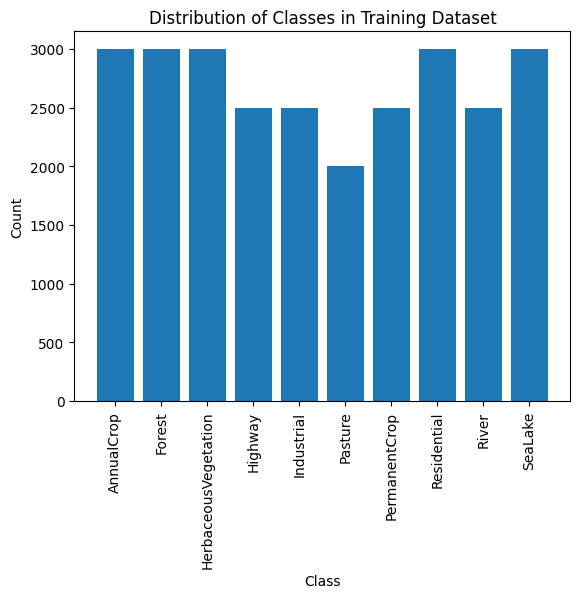

In [87]:
# display the distribution of classes in the training dataset
class_counts = Counter(y)
num_classes = len(class_names)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.title("Distribution of Classes in Training Dataset")
plt.show()

Data is distributed unequally, on "Pasture" label there are least examples.

next we'll show some random images and their labels:

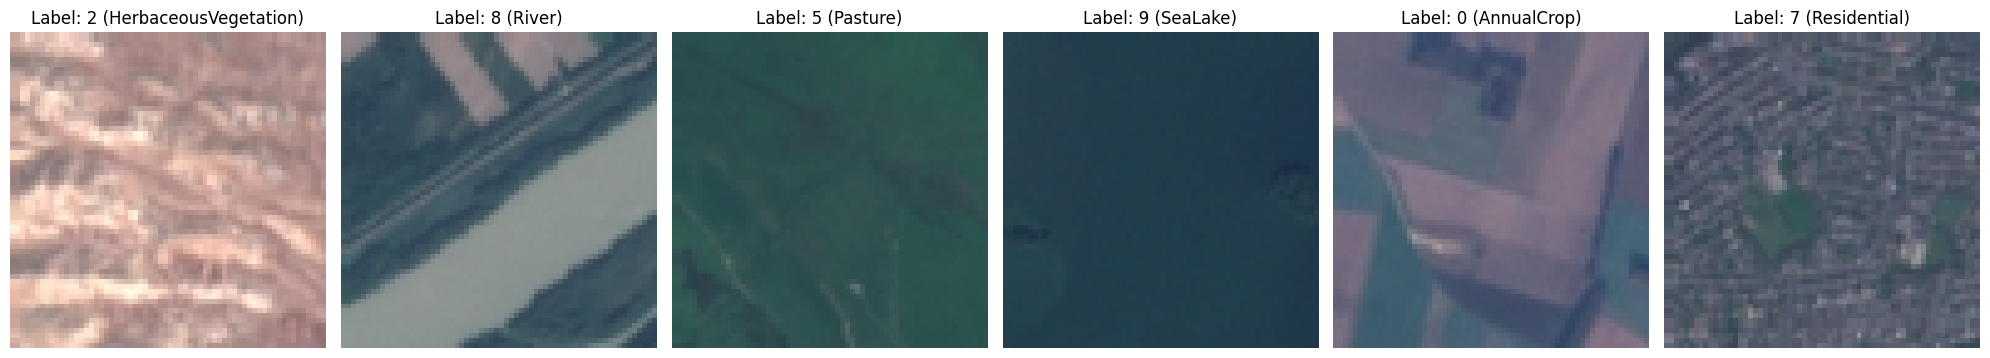

In [9]:
# Display some random sample images from the training dataset along with their labels
show_images(dataset, num_images=6)

### CNN Training

define variables:

In [10]:
EuroSAT_IMG_SIZE = (X_train.shape[1], X_train.shape[2])
Large_BATCH_SIZE = 128
Small_BATCH_SIZE = 64
Short_EPOCHS = 5
Long_EPOCHS = 20

In [11]:
# Split the training dataset into training and validation sets (80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

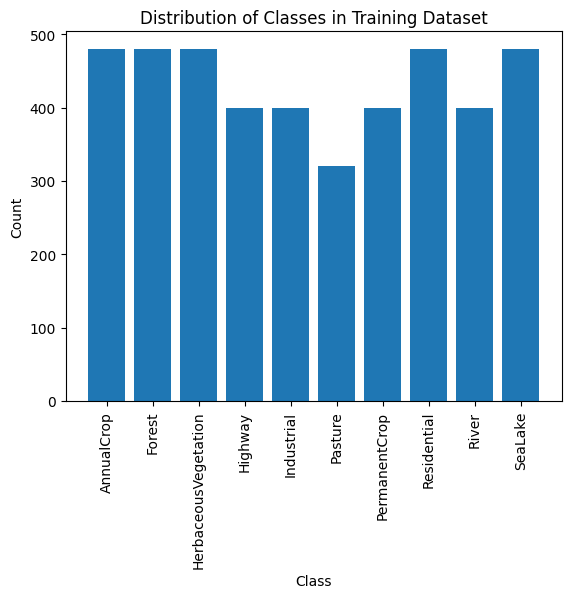

In [90]:
# display the distribution of classes in the training dataset
class_counts = Counter(y_val)
num_classes = len(class_names)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.title("Distribution of Classes in Training Dataset")
plt.show()

#### CNN With Data Augmentation

In [12]:
augmentation = keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=0.1),
    layers.RandomZoom(height_factor=0.1)
])

In [13]:
# Build a simple CNN model with 1 hidden layer
def build_cnn_1hidden(filters=32, kernel=3, dropout=0.3, dense_units=128):

    inputs = keras.Input(shape=(EuroSAT_IMG_SIZE[0], EuroSAT_IMG_SIZE[1], 3))
    x = augmentation(inputs)

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build a simple CNN model with 2 hidden layer
def build_cnn_2hidden(filters=32, kernel=3, dropout=0.3, dense_units=128):

    inputs = keras.Input(shape=(EuroSAT_IMG_SIZE[0], EuroSAT_IMG_SIZE[1], 3))
    x = augmentation(inputs)

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Build a simple CNN model with 3 hidden layer
def build_cnn(filters=32, kernel=3, dropout=0.3, dense_units=128):

    inputs = keras.Input(shape=(EuroSAT_IMG_SIZE[0], EuroSAT_IMG_SIZE[1], 3))
    x = augmentation(inputs)

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(filters*4, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
configs = [
    {"filters":32, "kernel":3, "dropout":0.5, "dense":128},
    {"filters":32, "kernel":3, "dropout":0.3, "dense":128},
    {"filters":32, "kernel":3, "dropout":0.5, "dense":256},
    {"filters":32, "kernel":3, "dropout":0.3, "dense":256},
    {"filters":64, "kernel":3, "dropout":0.5, "dense":128},
    {"filters":64, "kernel":3, "dropout":0.3, "dense":128},
    {"filters":64, "kernel":3, "dropout":0.5, "dense":256},
    {"filters":64, "kernel":3, "dropout":0.3, "dense":256},
]

#### HyperParameters Examine:

Examine 8 configurations of ***1*** hidden layer models:

In [15]:
import json

# File to store results in
RESULTS_FILE = "EuroSAT_cnn_1hidden_config_results.json"

# Load previous results if exist
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# internal function to check if a config has already been evaluated
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


for cfg in configs:

    if config_exists(cfg):
        print("Skipping existing config:", cfg)
        continue

    model = build_cnn_1hidden(
        filters=cfg["filters"],
        kernel=cfg["kernel"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val
    }

    results.append(result)

    # Save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(cfg, "->", best_val)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 82s 597ms/step - accuracy: 0.1839 - loss: 2.1305 - val_accuracy: 0.2435 - val_loss: 1.8846
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 125s 922ms/step - accuracy: 0.2652 - loss: 1.8530 - val_accuracy: 0.3090 - val_loss: 1.7890
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 124s 917ms/step - accuracy: 0.2991 - loss: 1.7821 - val_accuracy: 0.3419 - val_loss: 1.7402
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 124s 922ms/step - accuracy: 0.3274 - loss: 1.7399 - val_accuracy: 0.3859 - val_loss: 1.6956
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 127s 942ms/step - accuracy: 0.3628 - loss: 1.6848 - val_accuracy: 0.4333 - val_loss: 1.6389
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 127s 943ms/step - accuracy: 0.3944 - loss: 1.6342 - val_accuracy: 0.4458 - val_loss: 1.5748
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 126s 937ms/step - accuracy: 0.4146 - loss: 1.5763 - val_accuracy: 0.4657 - val_loss: 1.5233
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 127s 941ms/step - accuracy: 0.4406 - 

Examine 8 configurations of ***2*** hidden layer models:

In [16]:
import json

# File to store results in
RESULTS_FILE = "EuroSAT_cnn_2hidden_config_results.json"

# Load previous results if exist
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# internal function to check if a config has already been evaluated
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


for cfg in configs:

    if config_exists(cfg):
        print("Skipping existing config:", cfg)
        continue

    model = build_cnn_2hidden(
        filters=cfg["filters"],
        kernel=cfg["kernel"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val
    }

    results.append(result)

    # Save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(cfg, "->", best_val)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 383ms/step - accuracy: 0.2355 - loss: 1.9989 - val_accuracy: 0.3456 - val_loss: 1.7574
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 380ms/step - accuracy: 0.3418 - loss: 1.7111 - val_accuracy: 0.4241 - val_loss: 1.5605
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 53s 393ms/step - accuracy: 0.4479 - loss: 1.5148 - val_accuracy: 0.4618 - val_loss: 1.4742
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 379ms/step - accuracy: 0.4913 - loss: 1.4148 - val_accuracy: 0.5037 - val_loss: 1.3573
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 53s 391ms/step - accuracy: 0.5173 - loss: 1.3443 - val_accuracy: 0.5250 - val_loss: 1.3330
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 379ms/step - accuracy: 0.5430 - loss: 1.2902 - val_accuracy: 0.5544 - val_loss: 1.2608
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 382ms/step - accuracy: 0.5664 - loss: 1.2374 - val_accuracy: 0.5720 - val_loss: 1.1743
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 378ms/step - accuracy: 0.5795 - loss: 1

Examine 8 configurations of ***3*** hidden layer models:

In [17]:
import json

# File to store results in
RESULTS_FILE = "EuroSAT_cnn_3hidden_config_results.json"

# Load previous results if exist
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# internal function to check if a config has already been evaluated
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


for cfg in configs:

    if config_exists(cfg):
        print("Skipping existing config:", cfg)
        continue

    model = build_cnn(
        filters=cfg["filters"],
        kernel=cfg["kernel"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val
    }

    results.append(result)

    # Save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(cfg, "->", best_val)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 54s 399ms/step - accuracy: 0.2793 - loss: 1.8738 - val_accuracy: 0.4743 - val_loss: 1.4619
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 388ms/step - accuracy: 0.4786 - loss: 1.4162 - val_accuracy: 0.5356 - val_loss: 1.2896
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 382ms/step - accuracy: 0.5354 - loss: 1.2719 - val_accuracy: 0.5449 - val_loss: 1.2329
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 378ms/step - accuracy: 0.5810 - loss: 1.1639 - val_accuracy: 0.5884 - val_loss: 1.1304
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 378ms/step - accuracy: 0.6233 - loss: 1.0477 - val_accuracy: 0.6171 - val_loss: 1.0157
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 58s 433ms/step - accuracy: 0.6572 - loss: 0.9629 - val_accuracy: 0.6447 - val_loss: 0.9697
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 384ms/step - accuracy: 0.6755 - loss: 0.9136 - val_accuracy: 0.6840 - val_loss: 0.8552
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 51s 381ms/step - accuracy: 0.6960 - loss: 0

Load the 3 architecture files

In [18]:
df1 = load_results("EuroSAT_cnn_1hidden_config_results.json", "1 hidden")
df2 = load_results("EuroSAT_cnn_2hidden_config_results.json", "2 hidden")
df3 = load_results("EuroSAT_cnn_3hidden_config_results.json", "3 hidden")

top 2 configs of each file(1,2,3 hidden layers)

In [19]:
top1hidden = df1.sort_values("val_acc", ascending=False).head(2)
top2hidden = df2.sort_values("val_acc", ascending=False).head(2)
top3hidden = df3.sort_values("val_acc", ascending=False).head(2)

Combine them

In [20]:
top_models = pd.concat([top1hidden, top2hidden, top3hidden])

top_models = top_models.sort_values("val_acc", ascending=False)

top_models.drop(["history"], inplace=False, axis=1)

,model,filters,kernel,dropout,dense,train_acc,val_acc,train_loss,val_loss
7,3 hidden,64,3,0.3,256,0.814178,0.820602,0.529885,0.512031
4,3 hidden,64,3,0.5,128,0.772164,0.778935,0.650511,0.601235
7,2 hidden,64,3,0.3,256,0.737731,0.742130,0.731615,0.680743
2,2 hidden,32,3,0.5,256,0.707523,0.730093,0.820471,0.717465
1,1 hidden,32,3,0.3,128,0.573438,0.592593,1.221125,1.193949
7,1 hidden,64,3,0.3,256,0.575463,0.587500,1.186415,1.149014


Plot the training curves:

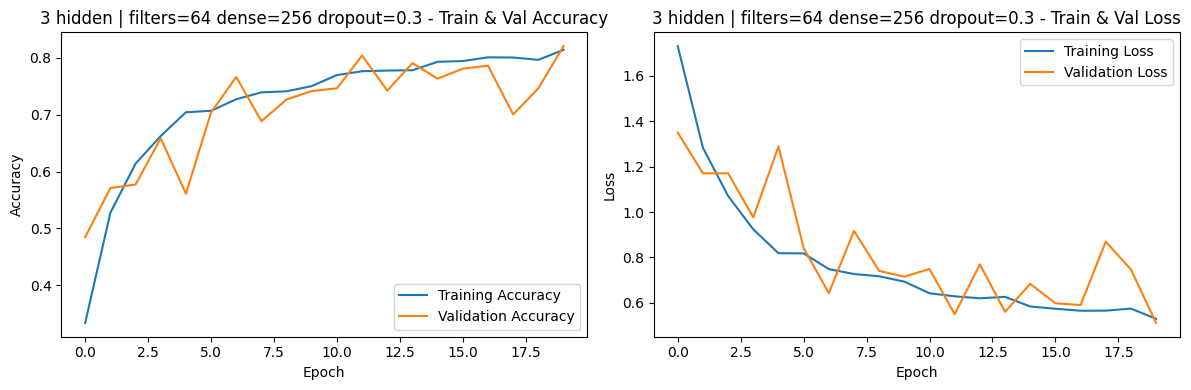

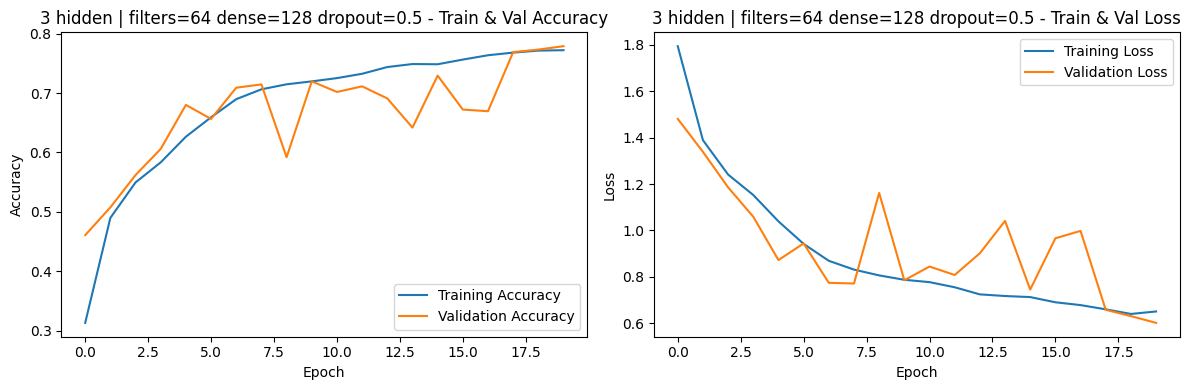

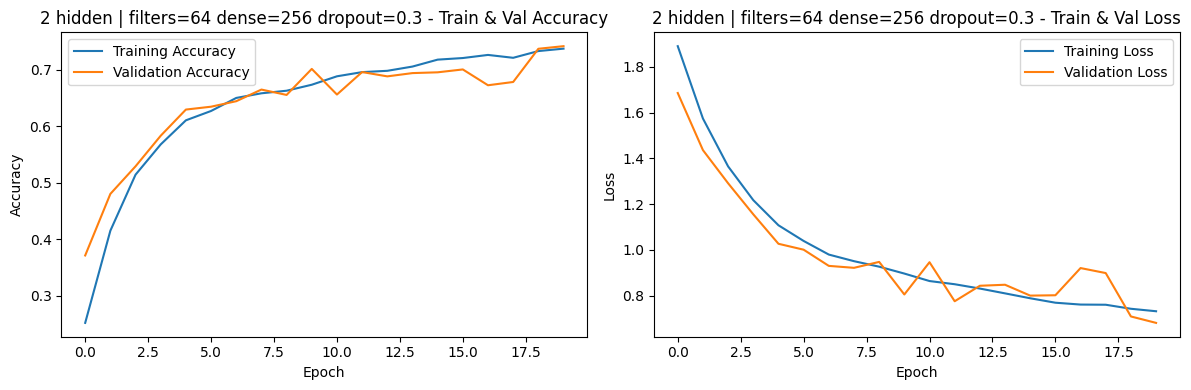

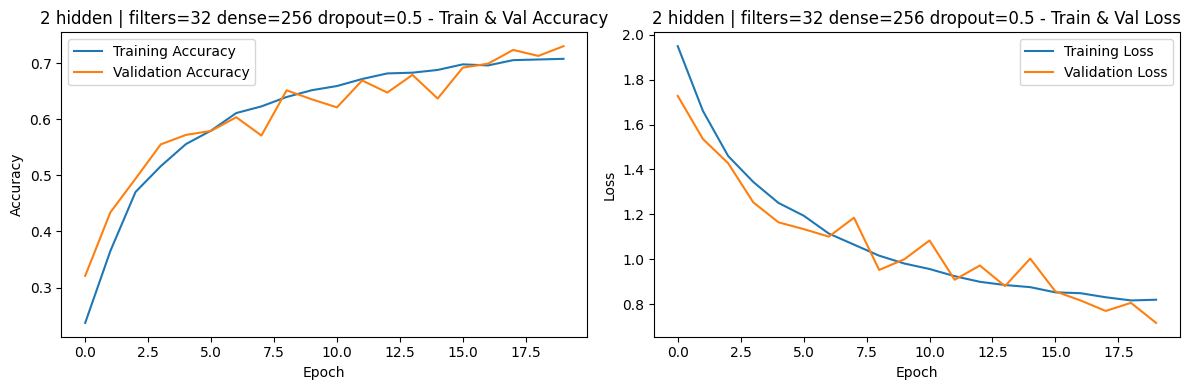

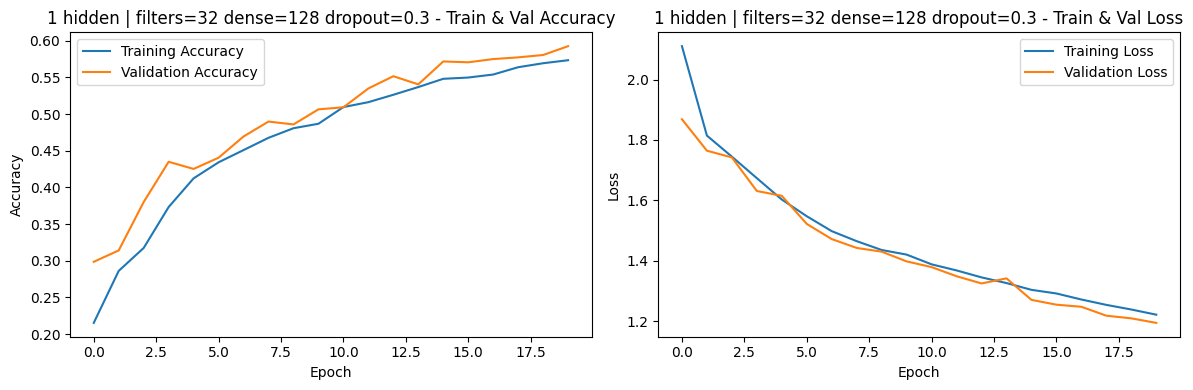

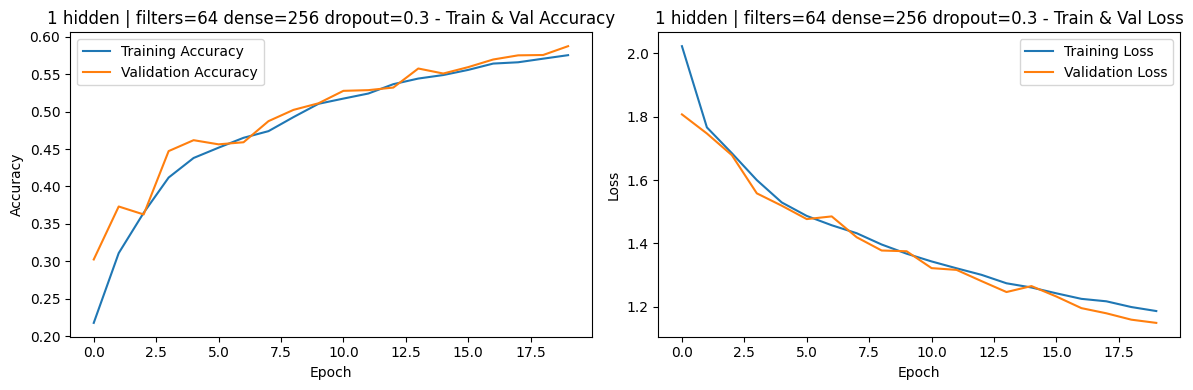

In [21]:
class HistoryWrapper:
    def __init__(self, history_dict):
        self.history = history_dict

for _, row in top_models.iterrows():

    name = (
        f"{row['model']} | "
        f"filters={row['filters']} "
        f"dense={row['dense']} "
        f"dropout={row['dropout']}"
    )

    plot_history(HistoryWrapper(row["history"]), name)

**Conclusions for the top 2 configs of each model used 1,2,3 hidden layers:**
1. 3 layers got the highest train&validation accuracies, lowest train&validation loss. more restrained from overfitting while using higher dropout.
2. seems like the models can train for more, the curves still go up/down.
3. the dataset is complex so we need deep models to deal with it, there are similar areas so the machine should learn deeper.

eventually, theres much of modifies that could be done and changes some can make for better results, we decided to work with the first model continue to the next part of the task.

In [22]:
best_model = top_models.iloc[0]

best_model

model                                                  3 hidden
filters                                                      64
kernel                                                        3
dropout                                                     0.3
dense                                                       256
train_acc                                              0.814178
val_acc                                                0.820602
train_loss                                             0.529885
val_loss                                               0.512031
history       {'config': {'filters': 64, 'kernel': 3, 'dropo...
Name: 7, dtype: object

Train our best cfg for 40 epochs:

In [23]:
RESULTS_FILE = "EuroSAT_cnn_best_cfg_results.json"

# best configuration selected
best_cfg = {
    "filters": int(best_model["filters"]),
    "kernel": int(best_model["kernel"]),
    "dropout": float(best_model["dropout"]),
    "dense": int(best_model["dense"])
}

# Load previous results
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# check if this config already exists
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


if config_exists(best_cfg):
    print("Skipping existing config:", best_cfg)

else:
    print("Training best configuration:", best_cfg)

    model = build_cnn(
        filters=best_cfg["filters"],
        kernel=best_cfg["kernel"],
        dropout=best_cfg["dropout"],
        dense_units=best_cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=Large_BATCH_SIZE
    )
    # Save the best model weights
    model.save_weights("EuroSAT_best_model.weights.h5")
    model.summary()
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Final test accuracy:", test_acc)
    print("Final test loss:", test_loss)

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": best_cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val,
        "test_acc": test_acc,
        "test_loss": test_loss
    }

    results.append(result)

    # save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=4)

    print(best_cfg, "->", best_val)

Training best configuration: {'filters': 64, 'kernel': 3, 'dropout': 0.3, 'dense': 256}
Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 57s 425ms/step - accuracy: 0.2965 - loss: 1.8032 - val_accuracy: 0.4148 - val_loss: 1.4990
Epoch 2/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 54s 400ms/step - accuracy: 0.4856 - loss: 1.3844 - val_accuracy: 0.5012 - val_loss: 1.4024
Epoch 3/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 54s 399ms/step - accuracy: 0.5637 - loss: 1.1850 - val_accuracy: 0.5907 - val_loss: 1.1143
Epoch 4/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 54s 397ms/step - accuracy: 0.6196 - loss: 1.0409 - val_accuracy: 0.6315 - val_loss: 0.9704
Epoch 5/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 53s 395ms/step - accuracy: 0.6649 - loss: 0.9197 - val_accuracy: 0.6611 - val_loss: 0.9272
Epoch 6/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 386ms/step - accuracy: 0.6899 - loss: 0.8469 - val_accuracy: 0.6590 - val_loss: 1.0337
Epoch 7/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 386ms/step - accuracy: 0.7111 - loss: 0.7906 - val_accuracy: 0.7069 - val_loss: 0.

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_24     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,536 (5.03 MB)

 Trainable params: 439,178 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 878,358 (3.35 MB)

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7783 - loss: 0.6497
Final test accuracy: 0.778333306312561
Final test loss: 0.649746835231781
{'filters': 64, 'kernel': 3, 'dropout': 0.3, 'dense': 256} -> 0.8599537014961243


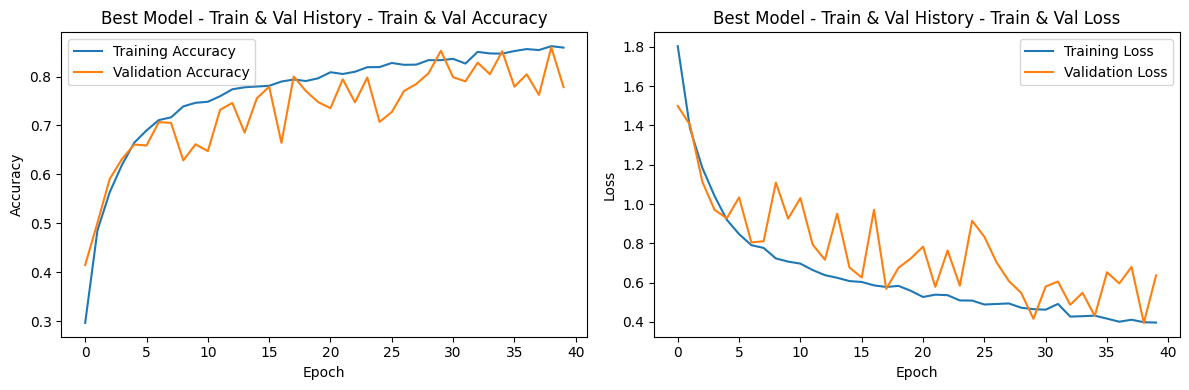

In [62]:
# load the best model weights and plot history
with open("EuroSAT_cnn_best_cfg_results.json", "r") as f:
    data = json.load(f)

plot_history(HistoryWrapper(data[-1]), "Best Model - Train & Val History")

### Transfer Learning

**`ResNet50`** - a 50 learning layers model using **residual learning**, where **skip connections** allow layers to learn the residual mapping between input and output.

**`MobileNetV2`**- a 17 learning layers model using **invert residual blocks** -> instead of traditional residual blocks that connect layers of the same depth, inverted residual blocks connect layers with different depths which help reducing computational complexity. use also **MBConv** blocks.

**`VGG16`**- a simple 16 learning layers CNN architecture, organized into blocks, with each block containing multiple convolutional layers followed by a max-pooling layer.

**`EfficientNetB0`**- a CNN architecture uses scaling to balance network depth, width, and input resolution. use also **MBConv** blocks.

1) *Residual Learning* learns the difference (residual) between the input and the desired output instead of learning the full transformation.

2) *skip connections* are shortcuts that allow information to bypass one or more layers and be added directly to a later layer, effectively preserving important information from earlier layers.

3) *invert residual blocks* connections are made between thin layers instead of wide layers, This design reduces computational cost.

4) *MBConv* include a structure of expansion layer which expands the number of channels(feature space). Depthwise convolution which apply each filter on one channel. SE which focus the useful parameters. Projection layer which reduce the channels again. skip connection to preserve important information.

In [63]:
models_to_test = {
    "MobileNetV2": keras.applications.MobileNetV2,
    "ResNet50": keras.applications.ResNet50,
    "EfficientNetB0": keras.applications.EfficientNetB0,
    "VGG16": keras.applications.VGG16
}

preprocess_map = {
    "MobileNetV2": keras.applications.mobilenet_v2.preprocess_input,
    "ResNet50": keras.applications.resnet.preprocess_input,
    "EfficientNetB0": keras.applications.efficientnet.preprocess_input,
    "VGG16": keras.applications.vgg16.preprocess_input
}

In [ ]:
def build_transfer_model(model_name, model_fn, dense_units=256, dropout=0.3):

    inputs = keras.Input(shape=(EuroSAT_IMG_SIZE[0], EuroSAT_IMG_SIZE[1], 3))

    x = layers.Resizing(224, 224)(inputs)   # on-the-fly resize because resizing the entire dataset resulted in memory issues

    # preprocess input according to the model's requirements
    preprocess_input = preprocess_map[model_name]
    x = preprocess_input(x)

    # Load the base model with pretrained weights and exclude the top layers
    base_model = model_fn(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )
    # Freeze the base model layers
    base_model.trainable = False
    
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes), activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

In [65]:
import gc # to clear GPU memory after each model training

for model_name, model_fn in models_to_test.items():
    # Clear GPU memory before each model training
    gc.collect()
    torch.cuda.empty_cache()

    RESULTS_FILE = f"{model_name}_results.json"

    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            results = json.load(f)
    else:
        results = []

    print("\nTraining model:", model_name)

    model, base_model = build_transfer_model(model_name, model_fn)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )
    # Save the best model weights and architecture
    model.save_weights(f"{model_name}.weights.h5")
    model.summary()
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Final test accuracy:", test_acc)
    print("Final test loss:", test_loss)

    best_val = max(history.history["val_accuracy"])

    result = {
        "model": model_name,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val,
        "test_acc": test_acc,
        "test_loss": test_loss
    }

    results.append(result)

    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(model_name, "->", best_val)


Training model: MobileNetV2
Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 101s 748ms/step - accuracy: 0.8649 - loss: 0.4083 - val_accuracy: 0.9303 - val_loss: 0.2107
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 75s 554ms/step - accuracy: 0.9271 - loss: 0.2182 - val_accuracy: 0.9373 - val_loss: 0.1955
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 72s 535ms/step - accuracy: 0.9395 - loss: 0.1772 - val_accuracy: 0.9310 - val_loss: 0.1946
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 74s 550ms/step - accuracy: 0.9473 - loss: 0.1508 - val_accuracy: 0.9396 - val_loss: 0.1794
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 74s 550ms/step - accuracy: 0.9538 - loss: 0.1282 - val_accuracy: 0.9375 - val_loss: 0.1882
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 73s 541ms/step - accuracy: 0.9640 - loss: 0.1025 - val_accuracy: 0.9375 - val_loss: 0.1782
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 72s 538ms/step - accuracy: 0.9660 - loss: 0.0978 - val_accuracy: 0.9438 - val_loss: 0.1773
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 73s 542ms/ste

Model: "functional_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_145 (InputLayer)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_63 (Resizing)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_11 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_11 (Subtract)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_84     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,249,504 (12.40 MB)

 Trainable params: 330,506 (1.26 MB)

...

 Total params: 15,116,384 (57.66 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 267,798 (1.02 MB)

169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.9530 - loss: 0.1671
Final test accuracy: 0.9529629349708557
Final test loss: 0.16705484688282013
VGG16 -> 0.9576388597488403


Sort the results in table dataFrame:

In [66]:
rows = []

for model_name, _ in models_to_test.items():
    
    file = f"{model_name}_results.json"
    
    if not os.path.exists(file):
        continue
        
    with open(file, "r") as f:
        results = json.load(f)
        
    # Find the best result based on validation accuracy
    best = max(results, key=lambda x: x["val_acc"])
    
    rows.append({
        "Model": model_name,
        "Best Val Accuracy": best["val_acc"],
        "Final Train Accuracy": best["accuracy"][-1],
        "Final Val Accuracy": best["val_accuracy"][-1],
        "Final Loss": best["loss"][-1],
        "Final Val Loss": best["val_loss"][-1],
        "Final Test Accuracy": best["test_acc"],
        "Final Test Loss": best["test_loss"]
    })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values("Best Val Accuracy", ascending=False)

df_results

,Model,Best Val Accuracy,Final Train Accuracy,Final Val Accuracy,Final Loss,Final Val Loss,Final Test Accuracy,Final Test Loss
1,ResNet50,0.968287,0.996412,0.962963,0.010421,0.151654,0.964444,0.153145
2,EfficientNetB0,0.964815,0.985127,0.964815,0.046213,0.123721,0.963704,0.119541
3,VGG16,0.957639,0.992130,0.951157,0.025724,0.180255,0.952963,0.167055
0,MobileNetV2,0.947222,0.991667,0.946759,0.027166,0.219069,0.946852,0.199744


Confusion Matrices:


Confusion Matrix for MobileNetV2
  1/169 ━━━━━━━━━━━━━━━━━━━━ 28s 170ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step


<Figure size 600x600 with 0 Axes>

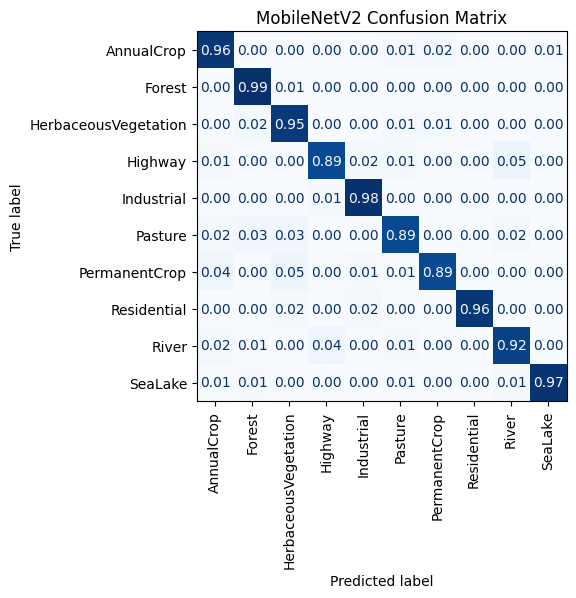


Confusion Matrix for ResNet50
  1/169 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step


<Figure size 600x600 with 0 Axes>

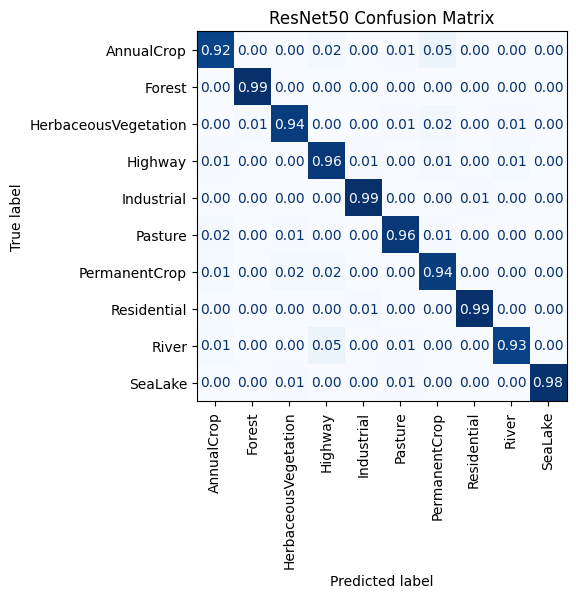


Confusion Matrix for EfficientNetB0
  1/169 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step


<Figure size 600x600 with 0 Axes>

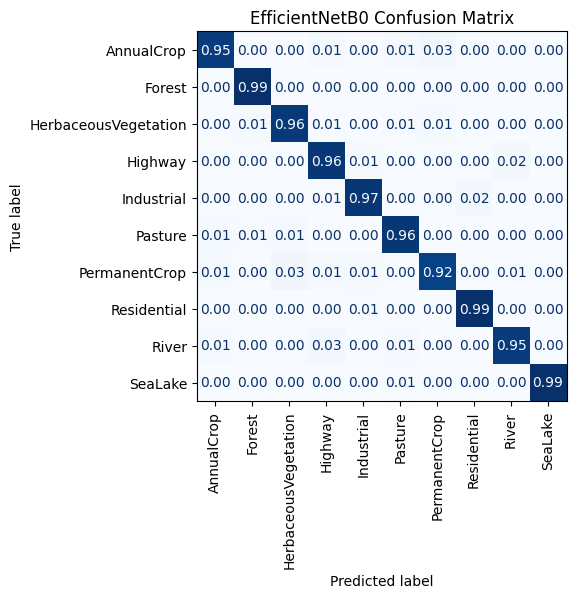


Confusion Matrix for VGG16
  1/169 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


169/169 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step


<Figure size 600x600 with 0 Axes>

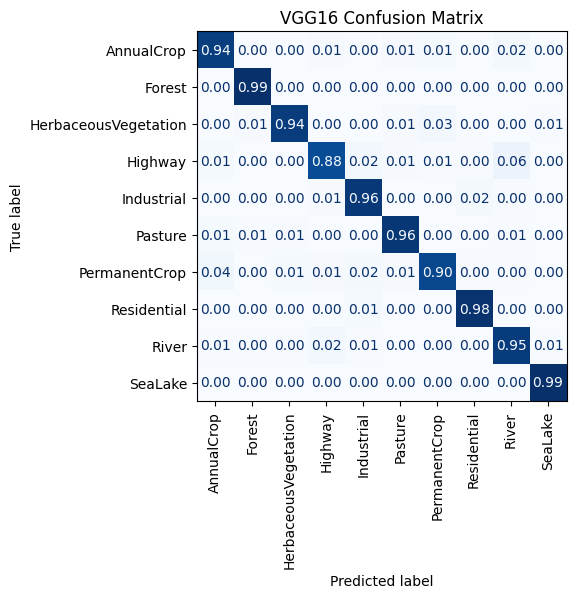

In [67]:
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

for model_name, model_fn in models_to_test.items():

    print(f"\nConfusion Matrix for {model_name}")

    # rebuild model
    model, base_model = build_transfer_model(model_name, model_fn)
    # load weights
    model.load_weights(f"{model_name}.weights.h5")

    # predict
    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred_labels, normalize='true')

    # display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(6,6))
    disp.plot(cmap="Blues", values_format=".2f", colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks(rotation=90)
    plt.show()

As we can see the most confusion happens in River vs Highway classifications, so we'll display random images of those from each model predicts:

In [68]:
def get_indices_by_condition(y_true, y_pred, true_class, pred_class, max_samples=6):
    indices = np.where((y_true == true_class) & (y_pred == pred_class))[0]
    
    if len(indices) == 0:
        return []
    
    return np.random.choice(indices, min(max_samples, len(indices)), replace=False)


Evaluating model: MobileNetV2
  2/169 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step 

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step


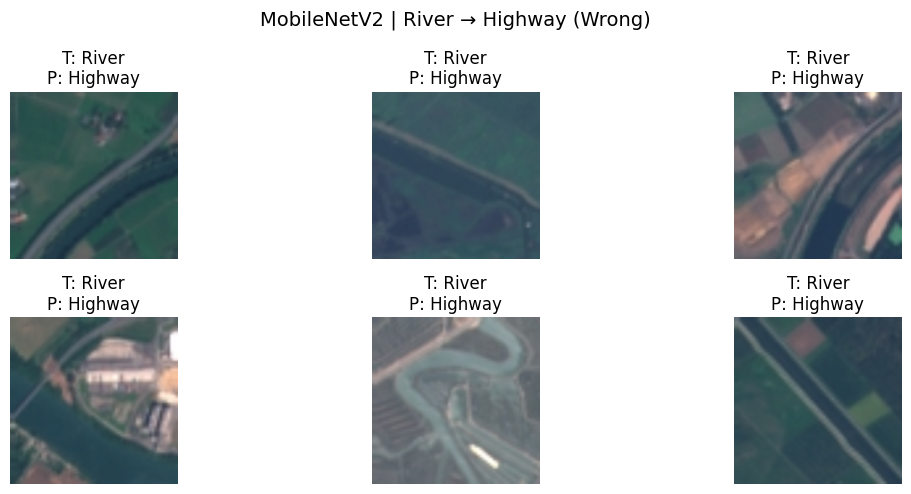

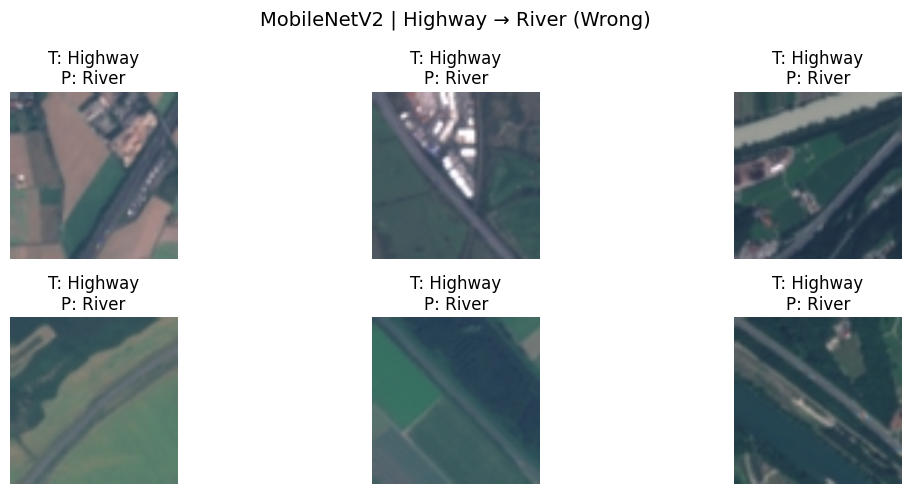

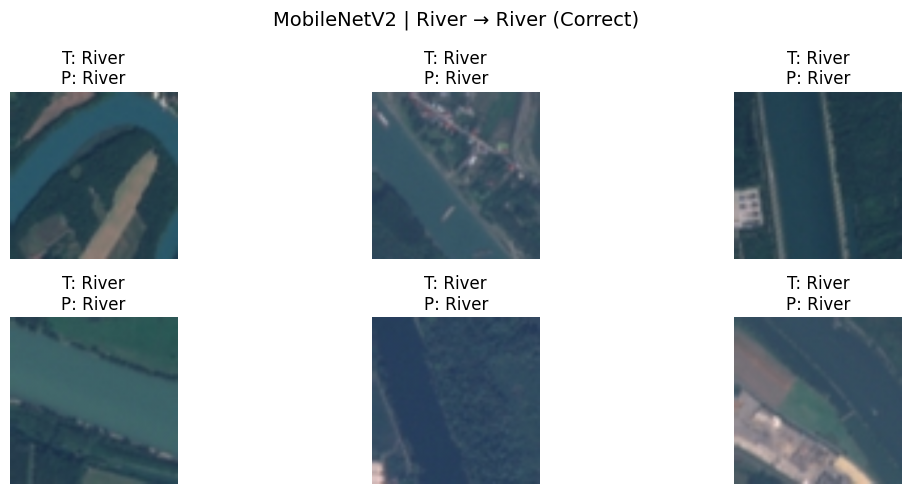


Evaluating model: ResNet50
169/169 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step


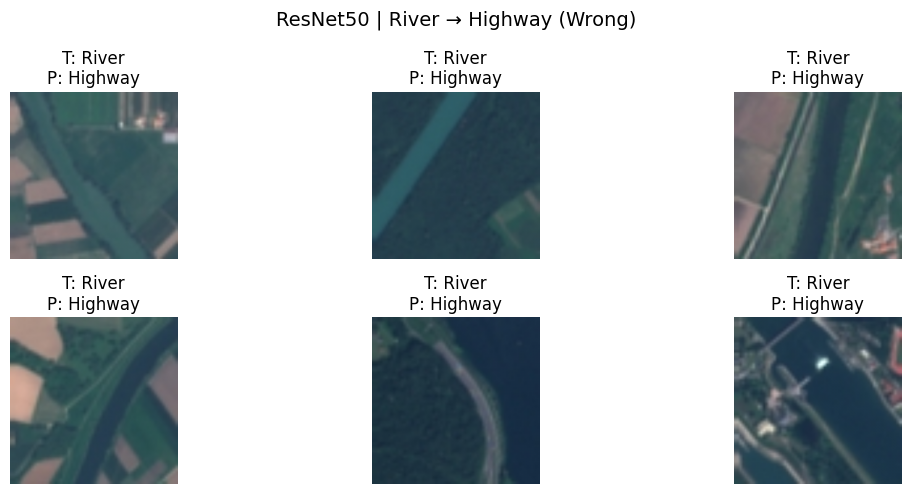

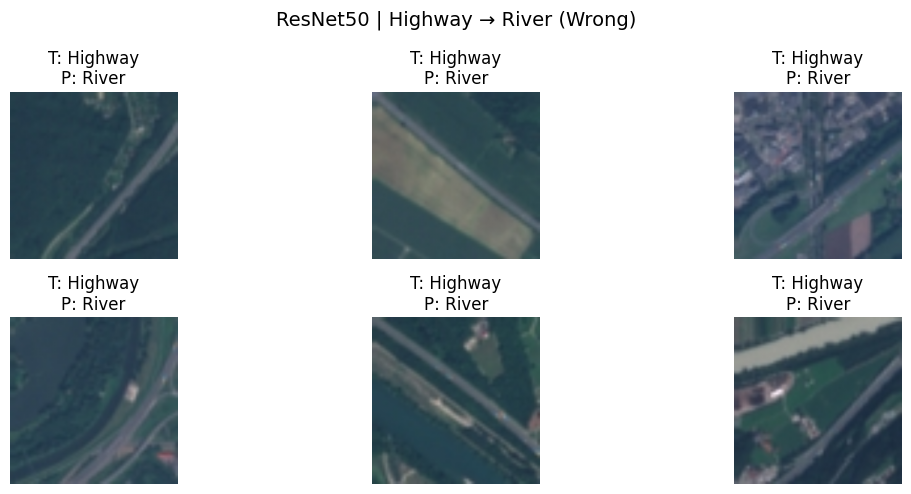

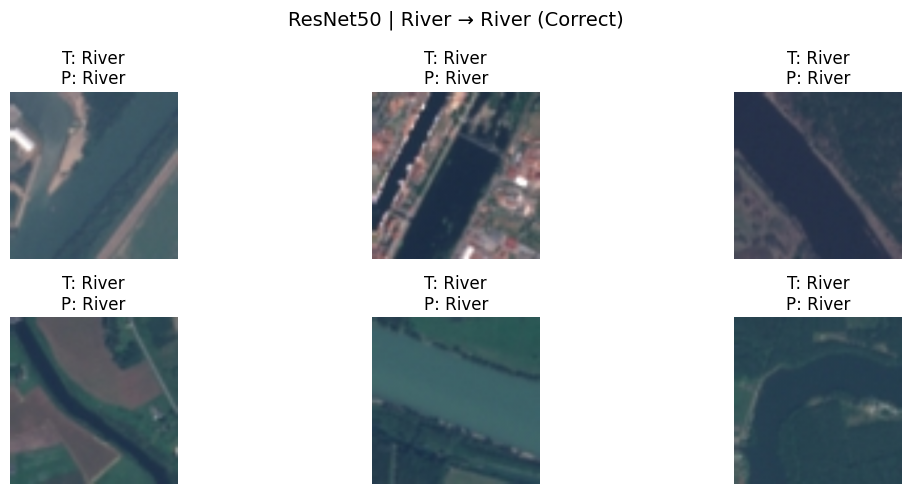


Evaluating model: EfficientNetB0
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step


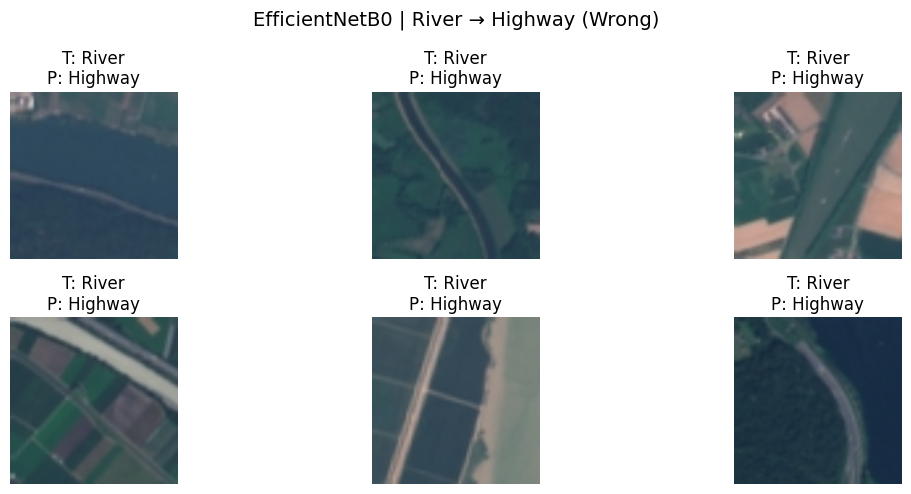

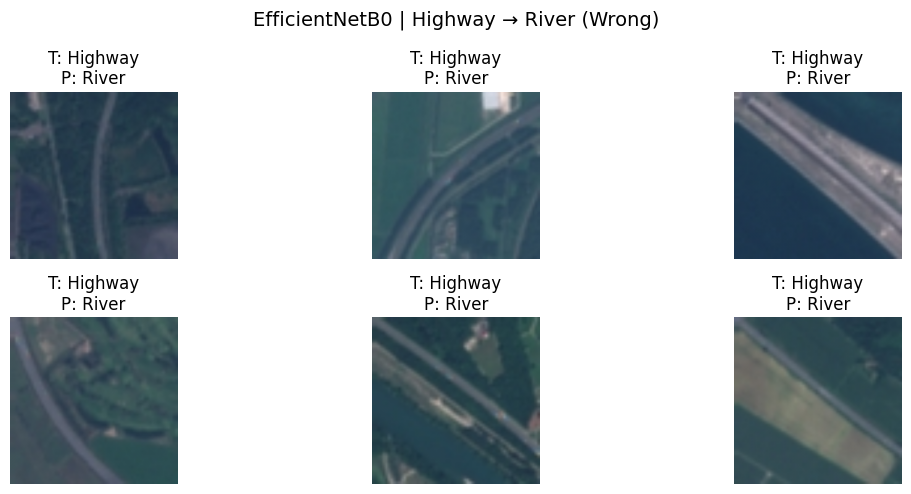

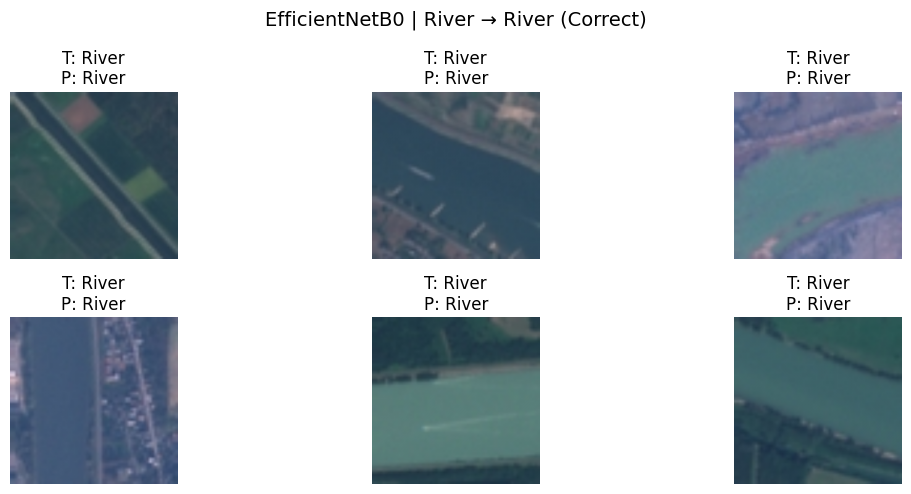


Evaluating model: VGG16
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step


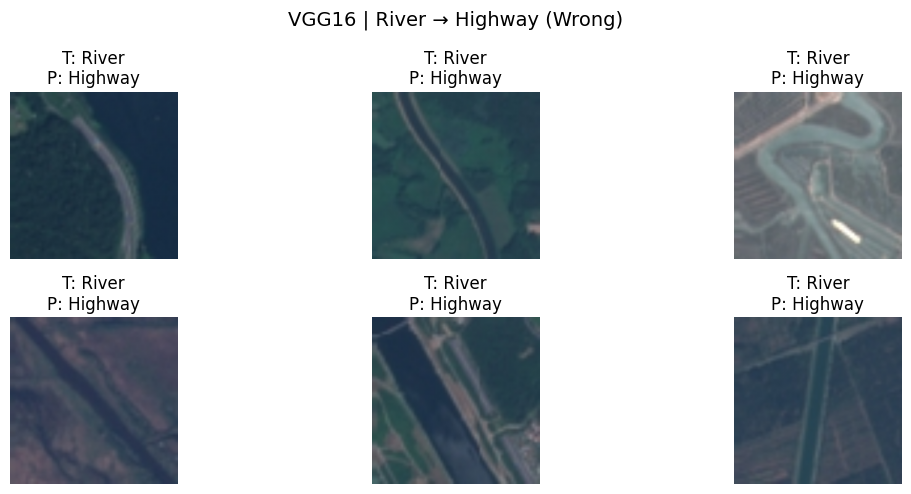

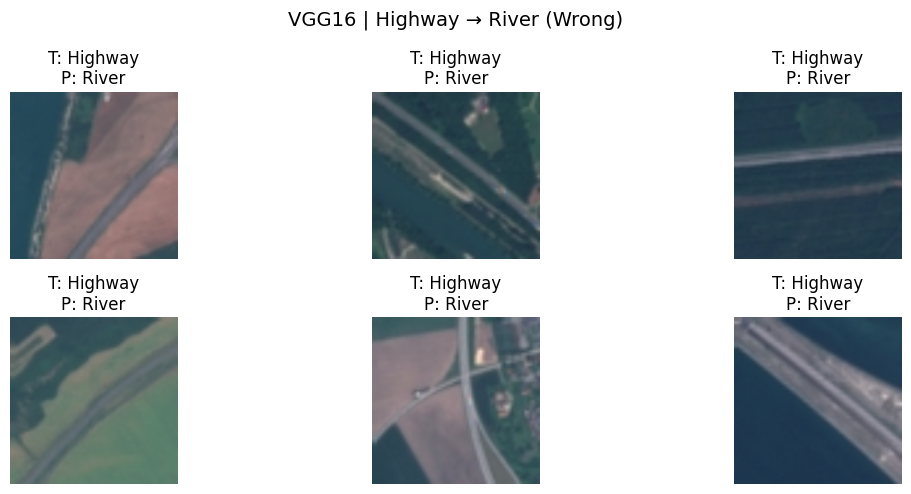

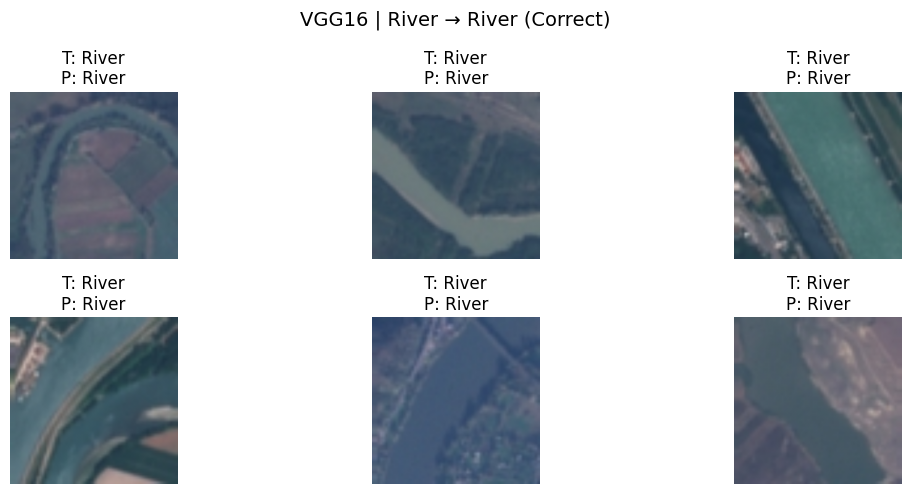

In [69]:
river_class = class_names.index("River")
highway_class = class_names.index("Highway")

resize_layer = keras.layers.Resizing(224,224)

for model_name, model_fn in models_to_test.items():

    print(f"\nEvaluating model: {model_name}")

    model, base_model = build_transfer_model(model_name, model_fn)
    model.load_weights(f"{model_name}.weights.h5")

    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # Get specific cases
    river_to_highway = get_indices_by_condition(y_true, y_pred_labels, river_class, highway_class)
    highway_to_river = get_indices_by_condition(y_true, y_pred_labels, highway_class, river_class)
    river_correct    = get_indices_by_condition(y_true, y_pred_labels, river_class, river_class)

    cases = [
        ("River → Highway (Wrong)", river_to_highway),
        ("Highway → River (Wrong)", highway_to_river),
        ("River → River (Correct)", river_correct)
    ]

    for title, indices in cases:

        if len(indices) == 0:
            print(f"{title}: No samples found")
            continue

        plt.figure(figsize=(12,5))
        plt.suptitle(f"{model_name} | {title}", fontsize=14)

        for i, idx in enumerate(indices):
            plt.subplot(2,3,i+1)

            img = resize_layer(X_test[idx:idx+1]).cpu().numpy()[0] / 255.0

            plt.imshow(img)
            plt.title(f"T: {class_names[y_true[idx]]}\nP: {class_names[y_pred_labels[idx]]}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

**Comparisons between those 4 transfer learning models:**

In the Transfer Learning stage on the EuroSAT dataset, all pretrained models achieved very high performance, indicating strong generalization of ImageNet's features to satellite images. Among the models, ResNet50 achieved the best results with ~0.964 test accuracy, followed closely by EfficientNetB0 (~0.963), while VGG16 and MobileNetV2 performed slightly lower (~0.952–0.947). Compared to CIFAR10 dataset, all models reached significantly higher accuracies, suggesting that EuroSAT’s structured classes are easier to separate using pretrained features, as we can see on the images above the structure of the images are shaped like diagonals, curved and straight lines with different but repetitive colors. However, despite the strong overall performance, the confusion matrix reveals consistent misclassification between “Highway” and “River”, likely due to their similar shapes and spatial patterns in satellite images such like a curved line that can be recognized as River or an Highway. Overall, transfer learning provides an excellent baseline on EuroSAT, with deeper architectures like ResNet50 demonstrating great feature extraction capabilities.

### FineTuning Of The Same Models

In [79]:
# Function to unfreeze top percent of total layers of the base model for fine-tuning
def unfreeze_top_percent(base_model, percent):

    base_model.trainable = True

    total_layers = len(base_model.layers)
    n_layers = max(1, int(total_layers * percent)) # at least unfreeze 1 layer

    print(f"Total layers: {total_layers}")
    print(f"Unfreezing last {n_layers} layers ({percent*100:.0f}%)")

    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False

In [80]:
import gc # to clear GPU memory after each model training

UNFREEZE_PERCENTS = [0.1, 0.2, 0.5] # hyperparameter to examine - unfreeze top 10%, 20%, or 50% of layers
FineTune_EPOCHS = 5

for model_name, model_fn in models_to_test.items():

    for percent in UNFREEZE_PERCENTS:

        # Clear GPU memory before each model training
        gc.collect()
        torch.cuda.empty_cache()

        RESULTS_FILE = f"{model_name}_finetune_results.json"

        if os.path.exists(RESULTS_FILE):
            with open(RESULTS_FILE, "r") as f:
                results = json.load(f)
        else:
            results = []

        print("\nFine-tuning model:", model_name, "| Unfreeze Percent:", percent*100, "%")

        # build model
        model, base_model = build_transfer_model(model_name, model_fn)

        # load transfer learning weights
        model.load_weights(f"{model_name}.weights.h5")

        # unfreeze last layers
        unfreeze_top_percent(base_model, percent)

        # recompile with small learning rate - to avoid large weight updates that can destroy the pretrained features
        model.compile(
            optimizer=keras.optimizers.Adam(1e-5),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=FineTune_EPOCHS,
            batch_size=Large_BATCH_SIZE
        )

        model.summary()
        test_loss, test_acc = model.evaluate(X_test, y_test)
        print("Final test accuracy:", test_acc)
        print("Final test loss:", test_loss)

        best_val = max(history.history["val_accuracy"])

        result = {
            "model": model_name,
            "unfreeze_percent": percent,
            "accuracy": history.history["accuracy"],
            "val_accuracy": history.history["val_accuracy"],
            "loss": history.history["loss"],
            "val_loss": history.history["val_loss"],
            "val_acc": best_val,
            "test_acc": test_acc,
            "test_loss": test_loss
        }

        results.append(result)

        with open(RESULTS_FILE, "w") as f:
            json.dump(results, f)

        print(model_name, "| unfreeze ", percent*100, "% ->", best_val)


Fine-tuning model: MobileNetV2 | Unfreeze Percent: 10.0 %
Total layers: 154
Unfreezing last 15 layers (10%)
Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 39s 283ms/step - accuracy: 0.8881 - loss: 0.4070 - val_accuracy: 0.9215 - val_loss: 0.3530
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 38s 282ms/step - accuracy: 0.9391 - loss: 0.1815 - val_accuracy: 0.9301 - val_loss: 0.2906
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 37s 277ms/step - accuracy: 0.9499 - loss: 0.1420 - val_accuracy: 0.9345 - val_loss: 0.2705
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 37s 276ms/step - accuracy: 0.9587 - loss: 0.1150 - val_accuracy: 0.9347 - val_loss: 0.2717
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 38s 278ms/step - accuracy: 0.9663 - loss: 0.0949 - val_accuracy: 0.9361 - val_loss: 0.2633


Model: "functional_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_197 (InputLayer)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_90 (Resizing)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_19 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_19 (Subtract)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_110    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_219 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_110 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_220 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,329,504 (20.33 MB)

 Trainable params: 1,370,506 (5.23 MB)

...

 Total params: 41,074,784 (156.69 MB)

 Trainable params: 13,113,098 (50.02 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 26,226,198 (100.05 MB)

169/169 ━━━━━━━━━━━━━━━━━━━━ 102s 603ms/step - accuracy: 0.9617 - loss: 0.1492
Final test accuracy: 0.9616666436195374
Final test loss: 0.1491813063621521
VGG16 | unfreeze  50.0 % -> 0.9634259343147278


In [81]:
rows = []

for model_name, _ in models_to_test.items():
    
    file = f"{model_name}_finetune_results.json"
    
    if not os.path.exists(file):
        continue
        
    with open(file, "r") as f:
        results = json.load(f)
        
    # Find the best result based on validation accuracy
    best = max(results, key=lambda x: x["val_acc"])
    
    rows.append({
        "Model": model_name,
        "Unfreeze Percent": best["unfreeze_percent"] * 100,
        "Best Val Accuracy": best["val_acc"],
        "Final Train Accuracy": best["accuracy"][-1],
        "Final Val Accuracy": best["val_accuracy"][-1],
        "Final Loss": best["loss"][-1],
        "Final Val Loss": best["val_loss"][-1],
        "Final Test Accuracy": best["test_acc"],
        "Final Test Loss": best["test_loss"]
    })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values("Best Val Accuracy", ascending=False)

df_results

,Model,Unfreeze Percent,Best Val Accuracy,Final Train Accuracy,Final Val Accuracy,Final Loss,Final Val Loss,Final Test Accuracy,Final Test Loss
1,ResNet50,50.0,0.969444,0.996354,0.969444,0.010092,0.130447,0.962222,0.165749
3,VGG16,50.0,0.963426,0.994907,0.963426,0.017492,0.155365,0.961667,0.149181
2,EfficientNetB0,10.0,0.948843,0.955671,0.948843,0.129058,0.204177,0.939815,0.217939
0,MobileNetV2,20.0,0.937500,0.961921,0.935880,0.107616,0.289144,0.932407,0.301519


In [82]:
rows = []

for model_name, _ in models_to_test.items():

    file = f"{model_name}_finetune_results.json"

    if not os.path.exists(file):
        continue

    with open(file, "r") as f:
        results = json.load(f)

    for r in results:

        rows.append({
            "Model": model_name,
            "Unfreeze Percent": r["unfreeze_percent"] * 100,
            "Best Val Accuracy": r["val_acc"],
            "Final Train Accuracy": r["accuracy"][-1],
            "Final Val Accuracy": r["val_accuracy"][-1],
            "Final Loss": r["loss"][-1],
            "Final Val Loss": r["val_loss"][-1],
            "Final Test Accuracy": r["test_acc"],
            "Final Test Loss": r["test_loss"]
        })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values(["Final Val Accuracy", "Model"], ascending=[False, True])

df_results

,Model,Unfreeze Percent,Best Val Accuracy,Final Train Accuracy,Final Val Accuracy,Final Loss,Final Val Loss,Final Test Accuracy,Final Test Loss
5,ResNet50,50.0,0.969444,0.996354,0.969444,0.010092,0.130447,0.962222,0.165749
3,ResNet50,10.0,0.967593,0.998611,0.967593,0.004982,0.142999,0.964074,0.155120
4,ResNet50,20.0,0.964583,0.996817,0.964120,0.009717,0.162068,0.963148,0.173424
11,VGG16,50.0,0.963426,0.994907,0.963426,0.017492,0.155365,0.961667,0.149181
10,VGG16,20.0,0.960648,0.998495,0.955556,0.007073,0.200082,0.955185,0.192315
9,VGG16,10.0,0.955324,0.995891,0.955324,0.017431,0.169921,0.955185,0.159236
6,EfficientNetB0,10.0,0.948843,0.955671,0.948843,0.129058,0.204177,0.939815,0.217939
8,EfficientNetB0,50.0,0.947917,0.937847,0.947917,0.200688,0.184064,0.943889,0.192331
7,EfficientNetB0,20.0,0.944444,0.943866,0.944444,0.177135,0.197460,0.942778,0.218486
0,MobileNetV2,10.0,0.936111,0.966262,0.936111,0.094899,0.263343,0.930185,0.269756


**Conclusions and comparisons Transfer Learning vs FineTuning:**

On the EuroSAT dataset, Transfer Learning already achieves strong performance as the models effectively capture the dataset’s dominant texture and geometric patterns (straight, curved lines and repetitive structures) using pretrained ImageNet features. It is hard to say whether FineTuning generally improves or worsens. The effectiveness of FineTuning can be inferred by observation of the dataset similarity, baseline Transfer Learning performance and validation behavior. When the dataset is aligned with pretrained features and Transfer Learning already achieves high accuracy, FineTuning may provide limited benefit or even degrade performance due to overfitting. This indicates that EuroSAT requires minimal adaptation, as its visual characteristics align well with features learned during pretraining. Overall, Transfer Learning is sufficient, while FineTuning must be applied cautiously, as aggressive unfreezing can harm performance.